# Aula prática — Desenvolvimento de pipelines de aprendizado de máquina

**Tema:** Construção de pipelines com Python e Scikit-learn  
**Objetivo:** organizar um fluxo completo de aprendizado de máquina, desde os dados até a avaliação do modelo.

## O que vamos praticar

- carregar e explorar dados;
- separar variáveis de entrada e variável alvo;
- dividir dados em treino e teste;
- aplicar pré-processamento;
- construir um pipeline com Scikit-learn;
- treinar um modelo;
- avaliar resultados;
- resolver exercícios práticos.

## Ideia central

> Um pipeline organiza as etapas de processamento e treinamento para tornar o fluxo de IA mais claro, reutilizável e menos sujeito a erros.

# 1. Importando as bibliotecas

Nesta aula usaremos `pandas`, `numpy`, `matplotlib` e `scikit-learn`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Criando um conjunto de dados

Vamos trabalhar com um exemplo simples: previsão de desempenho acadêmico.

A variável que queremos prever será `nota_final`.

As variáveis de entrada serão:

- `horas_estudo`
- `faltas`
- `participacao`
- `atividades_entregues`

In [ ]:
dados = {
    "horas_estudo": [2, 4, 6, 8, 3, 5, 7, 1, 9, 10, 4, 6, 8, 2, 5],
    "faltas": [8, 5, 3, 1, 7, 4, 2, 10, 1, 0, 6, 3, 2, 9, 4],
    "participacao": [4, 6, 7, 9, 5, 6, 8, 3, 9, 10, 5, 7, 8, 4, 6],
    "atividades_entregues": [3, 5, 6, 8, 4, 6, 7, 2, 9, 10, 5, 7, 8, 3, 6],
    "nota_final": [5.0, 6.5, 7.5, 9.0, 5.8, 7.0, 8.2, 4.0, 9.3, 9.8, 6.2, 7.6, 8.5, 4.8, 7.1]
}

df = pd.DataFrame(dados)
df

,horas_estudo,faltas,participacao,atividades_entregues,nota_final
0,2,8,4,3,5.0
1,4,5,6,5,6.5
2,6,3,7,6,7.5
3,8,1,9,8,9.0
4,3,7,5,4,5.8
5,5,4,6,6,7.0
6,7,2,8,7,8.2
7,1,10,3,2,4.0
8,9,1,9,9,9.3
9,10,0,10,10,9.8


# 3. Explorando os dados

In [ ]:
df.head()

,horas_estudo,faltas,participacao,atividades_entregues,nota_final
0,2,8,4,3,5.0
1,4,5,6,5,6.5
2,6,3,7,6,7.5
3,8,1,9,8,9.0
4,3,7,5,4,5.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   horas_estudo          15 non-null     int64  
 1   faltas                15 non-null     int64  
 2   participacao          15 non-null     int64  
 3   atividades_entregues  15 non-null     int64  
 4   nota_final            15 non-null     float64
dtypes: float64(1), int64(4)
memory usage: 732.0 bytes


In [ ]:
df.describe()

,horas_estudo,faltas,participacao,atividades_entregues,nota_final
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,5.333333,4.333333,6.466667,5.933333,7.086667
std,2.716791,3.086067,2.065591,2.313521,1.721655
min,1.000000,0.000000,3.000000,2.000000,4.000000
25%,3.500000,2.000000,5.000000,4.500000,6.000000
50%,5.000000,4.000000,6.000000,6.000000,7.100000
75%,7.500000,6.500000,8.000000,7.500000,8.350000
max,10.000000,10.000000,10.000000,10.000000,9.800000


## Exercício 1

Mostre:

1. as 3 primeiras linhas do dataset;
2. as 3 últimas linhas;
3. a quantidade de linhas e colunas.

In [ ]:
# Resolva aqui o Exercício 1

# 4. Visualização inicial

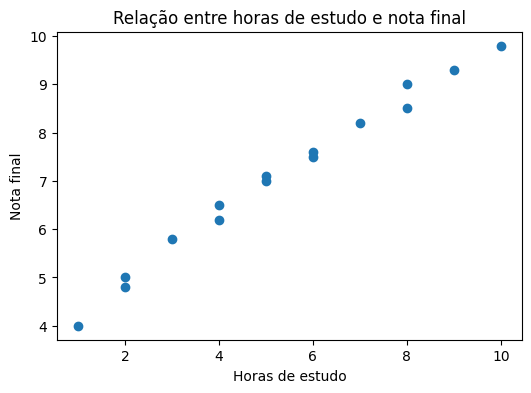

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df["horas_estudo"], df["nota_final"])
plt.xlabel("Horas de estudo")
plt.ylabel("Nota final")
plt.title("Relação entre horas de estudo e nota final")
plt.show()

## Exercício 2

Crie um gráfico de dispersão mostrando a relação entre `faltas` e `nota_final`.

Depois, escreva uma breve interpretação.

In [ ]:
# Resolva aqui o Exercício 2

# 5. Separando entradas e saída

Em aprendizado supervisionado, normalmente separamos:

- `X`: variáveis de entrada;
- `y`: variável alvo.

In [ ]:
X = df[["horas_estudo", "faltas", "participacao", "atividades_entregues"]]
y = df["nota_final"]

X.head()

,horas_estudo,faltas,participacao,atividades_entregues
0,2,8,4,3
1,4,5,6,5
2,6,3,7,6
3,8,1,9,8
4,3,7,5,4


In [ ]:
y.head()

,nota_final
0,5.0
1,6.5
2,7.5
3,9.0
4,5.8


## Exercício 3

Crie uma nova variável `X_simples` contendo apenas:

- `horas_estudo`
- `faltas`

Depois, mostre as primeiras linhas.

In [ ]:
# Resolva aqui o Exercício 3

# 6. Dividindo os dados em treino e teste

A divisão entre treino e teste permite verificar se o modelo consegue generalizar para dados que ele ainda não viu.

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Quantidade de dados de treino:", len(X_treino))
print("Quantidade de dados de teste:", len(X_teste))

Quantidade de dados de treino: 10
Quantidade de dados de teste: 5


## Exercício 4

Explique com suas palavras:

1. Por que dividimos os dados em treino e teste?
2. O que pode acontecer se avaliarmos o modelo apenas com os dados usados no treinamento?

**Resposta:**

Escreva sua resposta aqui.

# 7. Criando um pipeline

Agora vamos criar um pipeline com duas etapas:

1. `StandardScaler`: padroniza os dados;
2. `LinearRegression`: treina um modelo de regressão linear.

In [ ]:
pipeline = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", LinearRegression())
])

pipeline

Pipeline(steps=[('padronizacao', StandardScaler()),
                ('modelo', LinearRegression())])

# 8. Treinando o pipeline

Quando chamamos `.fit()`, o pipeline executa as etapas em sequência:

1. padroniza os dados de treino;
2. treina o modelo.

In [ ]:
pipeline.fit(X_treino, y_treino)

# 9. Fazendo previsões

In [ ]:
previsoes = pipeline.predict(X_teste)
previsoes

In [ ]:
resultado = pd.DataFrame({
    "Nota real": y_teste.values,
    "Nota prevista": previsoes
})

resultado

## Exercício 5

Crie uma nova coluna chamada `erro`, calculando:

`erro = Nota real - Nota prevista`

Depois, mostre a tabela.

In [ ]:
# Resolva aqui o Exercício 5

# 10. Avaliando o modelo

Vamos usar três métricas simples:

- **MAE:** erro médio absoluto;
- **MSE:** erro quadrático médio;
- **R²:** indica o quanto o modelo explica a variação dos dados.

In [ ]:
mae = mean_absolute_error(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

## Exercício 6

Interprete os resultados:

1. O erro parece alto ou baixo?
2. O modelo parece adequado para esse conjunto de dados?
3. O que poderia ser melhorado?

**Resposta:**

Escreva sua resposta aqui.

# 11. Fazendo previsão para um novo aluno

In [ ]:
novo_aluno = pd.DataFrame({
    "horas_estudo": [6],
    "faltas": [2],
    "participacao": [8],
    "atividades_entregues": [7]
})

nota_prevista = pipeline.predict(novo_aluno)

print("Nota prevista:", nota_prevista[0])

## Exercício 7

Crie dois novos alunos:

1. um com perfil de alto desempenho;
2. outro com perfil de baixo desempenho.

Use o pipeline para prever a nota dos dois.

In [ ]:
# Resolva aqui o Exercício 7

# 12. Comparando com um pipeline mais simples

Agora vamos usar apenas duas variáveis:

- `horas_estudo`
- `faltas`

O objetivo é comparar se usar menos variáveis muda o desempenho.

In [ ]:
X_simples = df[["horas_estudo", "faltas"]]

X_treino_s, X_teste_s, y_treino_s, y_teste_s = train_test_split(
    X_simples, y, test_size=0.3, random_state=42
)

pipeline_simples = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", LinearRegression())
])

pipeline_simples.fit(X_treino_s, y_treino_s)

previsoes_s = pipeline_simples.predict(X_teste_s)

mae_s = mean_absolute_error(y_teste_s, previsoes_s)
mse_s = mean_squared_error(y_teste_s, previsoes_s)
r2_s = r2_score(y_teste_s, previsoes_s)

print("MAE:", mae_s)
print("MSE:", mse_s)
print("R²:", r2_s)

## Exercício 8

Compare o pipeline completo com o pipeline simples.

Responda:

1. Qual teve menor erro?
2. Qual teve maior R²?
3. Usar mais variáveis melhorou o resultado?
4. Por que isso pode acontecer?

**Resposta:**

Escreva sua resposta aqui.

# 13. Desafio final

Crie um novo dataset com pelo menos 10 registros contendo:

- `idade`
- `horas_estudo`
- `faltas`
- `participacao`
- `nota_final`

Depois:

1. crie o DataFrame;
2. separe `X` e `y`;
3. divida treino e teste;
4. crie um pipeline com `StandardScaler` e `LinearRegression`;
5. treine o pipeline;
6. faça previsões;
7. avalie usando MAE, MSE e R²;
8. escreva uma breve interpretação dos resultados.

In [ ]:
# Resolva aqui o desafio final